# Green's function and effective window of the implicit filter (W2.0)

For the **W2.0** configuration ($\ell = 63.5$ km at the equator, a "2° box equivalent"), this notebook compares the implicit filter with a Gaussian and a top-hat (box) kernel. All three have the **same second moment** $\langle r^2\rangle = 2\ell^2$.

- **Panel A:** kernel $G(r)$ in physical space, normalised to unit 2D integral, on a log axis.
- **Panel B:** energy transfer function $G^2(\lambda)$.

**Kernels** ($K = 2\pi/\lambda$):

| | $G(r)$ | $\hat G(K)$ | $\langle r^2\rangle$ |
|---|---|---|---|
| Implicit | $\dfrac{1}{\pi\ell^2}K_0\!\left(\dfrac{\sqrt2\,r}{\ell}\right)$ | $\dfrac{1}{1+\tfrac12\ell^2K^2}$ | $2\ell^2$ |
| Gaussian, $\sigma=\ell$ | $\dfrac{1}{2\pi\ell^2}e^{-r^2/2\ell^2}$ | $e^{-\ell^2K^2/2}$ | $2\ell^2$ |
| Box (disk, radius $R$) | $\dfrac{1}{\pi R^2}$ for $r<R$ | $\mathrm{jinc}(KR)=\dfrac{2J_1(KR)}{KR}$ | $R^2/2$ |

**Two notes on the task formulas.**
1. **Normalization.** $\frac{1}{2\pi\ell^2}K_0(\sqrt2 r/\ell)$ integrates to ½ in 2D. It is the Green's function of $1-\ell^2\nabla^2$ rescaled, not of $1-\tfrac12\ell^2\nabla^2$. The prefactor is therefore $1/(\pi\ell^2)$; the notebook also normalises numerically.
2. **Box radius.** A disk matched to $\langle r^2\rangle = 2\ell^2$ needs $R = 2\ell$ (127 km). $R=\ell\sqrt6$ comes from a 1D box width $L=\sqrt{12}\,\ell$ divided by √2, and gives $\langle r^2\rangle = 3\ell^2$: a 50 % larger second moment and a half-power wavelength of 605 km instead of 494 km. The figure uses the matched $R=2\ell$; both values are printed below.

**Equivalently:** the 2° square box of side $L = \sqrt{12}\,\ell$ = 222 km has $\langle r^2\rangle = L^2/6 = 2\ell^2$, the same as all three kernels here.

In [1]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k0, j1
from scipy.integrate import quad
from scipy.optimize import brentq

ell = 63.5                      # km, W2.0 at the equator
R = 2.0 * ell                   # top-hat radius with <r^2> = 2 ell^2
R_task = np.sqrt(6) * ell       # value in the task sheet (<r^2> = 3 ell^2), for reference
DEG = 111.2                     # km per degree at the equator

# --- kernels, normalised numerically to unit 2D integral
def implicit_raw(r): return k0(np.sqrt(2) * r / ell)
def gauss_raw(r):    return np.exp(-r**2 / (2 * ell**2))
norm_imp = 2 * np.pi * quad(lambda r: r * implicit_raw(r), 0, np.inf)[0]
norm_gau = 2 * np.pi * quad(lambda r: r * gauss_raw(r), 0, np.inf)[0]
G_imp = lambda r: implicit_raw(r) / norm_imp
G_gau = lambda r: gauss_raw(r) / norm_gau
G_box = lambda r: np.where(r < R, 1 / (np.pi * R**2), 0.0)

# checks: normalisation and second moments
m2 = lambda G, rmax: 2*np.pi*quad(lambda r: r**3 * G(r), 0, rmax, limit=200)[0]
print(f'implicit: 1/(2 pi l^2) K0 integrates to {2*np.pi*quad(lambda r: r*implicit_raw(r),0,np.inf)[0]/(2*np.pi*ell**2):.3f}'
      f' -> prefactor 1/(pi l^2); numeric norm = {1/norm_imp*np.pi*ell**2:.4f} x 1/(pi l^2)')
print(f'<r^2>/ell^2: implicit {m2(G_imp, np.inf)/ell**2:.3f}   gaussian {m2(G_gau, np.inf)/ell**2:.3f}   box R=2l {R**2/2/ell**2:.3f}   box R=l*sqrt6 {R_task**2/2/ell**2:.3f}')

# --- transfer functions (energy)
jinc = lambda x: np.where(np.abs(x) < 1e-8, 1.0, 2 * j1(x) / np.where(np.abs(x) < 1e-8, 1, x))
T_imp = lambda lam: 1 / (1 + 0.5 * ell**2 * (2*np.pi/lam)**2)**2
T_gau = lambda lam: np.exp(-ell**2 * (2*np.pi/lam)**2)
T_box = lambda lam, RR=R: jinc(RR * 2*np.pi/lam)**2

# half-power wavelengths (largest lambda where G^2 = 0.5)
lam_half = {'implicit': brentq(lambda l: T_imp(l) - 0.5, 50, 3000),
            'gaussian': brentq(lambda l: T_gau(l) - 0.5, 50, 3000),
            'box':      brentq(lambda l: T_box(l) - 0.5, 150, 3000)}
lam_half_task = brentq(lambda l: T_box(l, R_task) - 0.5, 150, 3000)
for k, v in lam_half.items():
    print(f'half-power wavelength {k:9s}: {v:6.0f} km  ({v/ell:.2f} ell)')
print(f'(box with the task-sheet R = l*sqrt6 = {R_task:.0f} km would give {lam_half_task:.0f} km)')

# e-folding radii
r_e_gau = np.sqrt(2) * ell              # G(r)/G(0) = 1/e
r_e_imp = ell / np.sqrt(2)              # tail decay length: K0(x) ~ sqrt(pi/2x) e^-x ; G(0) is singular (log)
for lam_ in (200, 300, 450, 1000, 1300):
    print(f'G^2 at {lam_:4d} km: implicit {T_imp(lam_):.2f}  gaussian {T_gau(lam_):.2f}  box {float(T_box(lam_)):.2f}')
print(f'e-folding: gaussian r_e = {r_e_gau:.0f} km (G/G0 = 1/e);  implicit decay length = {r_e_imp:.0f} km (tail ~ e^(-r/{r_e_imp:.0f} km));  box edge R = {R:.0f} km')

implicit: 1/(2 pi l^2) K0 integrates to 0.500 -> prefactor 1/(pi l^2); numeric norm = 1.0000 x 1/(pi l^2)
<r^2>/ell^2: implicit 2.000   gaussian 2.000   box R=2l 2.000   box R=l*sqrt6 3.000
half-power wavelength implicit :    438 km  (6.90 ell)
half-power wavelength gaussian :    479 km  (7.55 ell)
half-power wavelength box      :    494 km  (7.77 ell)
(box with the task-sheet R = l*sqrt6 = 156 km would give 605 km)
G^2 at  200 km: implicit 0.11  gaussian 0.02  box 0.00
G^2 at  300 km: implicit 0.28  gaussian 0.17  box 0.12
G^2 at  450 km: implicit 0.52  gaussian 0.46  box 0.43
G^2 at 1000 km: implicit 0.86  gaussian 0.85  box 0.85
G^2 at 1300 km: implicit 0.91  gaussian 0.91  box 0.91
e-folding: gaussian r_e = 90 km (G/G0 = 1/e);  implicit decay length = 45 km (tail ~ e^(-r/45 km));  box edge R = 127 km


**About "e-folding radius".**
- **Gaussian:** the usual definition applies. $G(r)/G(0)=e^{-1}$ at $r_e=\sqrt2\,\ell$ = 90 km.
- **Implicit kernel:** $K_0$ has an integrable log singularity at $r=0$, so $G(0)$ is infinite and a ratio to $G(0)$ is undefined. Its tail decays as $e^{-\sqrt2 r/\ell}$, so the natural e-folding **length** is $\ell/\sqrt2$ = 45 km. That short e-folding length hides the **long tail**: at $r = 500$ km the implicit kernel is still $e^{-11}$ of its near-field level, while the Gaussian has dropped to $e^{-31}$.
- **Box:** it has no e-folding; its edge $R$ is marked instead.

saved /work/bk1450/b383184/Amazon/Mercator/implicit_run/analysis/greens_function
/mnt/user-data/outputs does not exist on this system - not copied


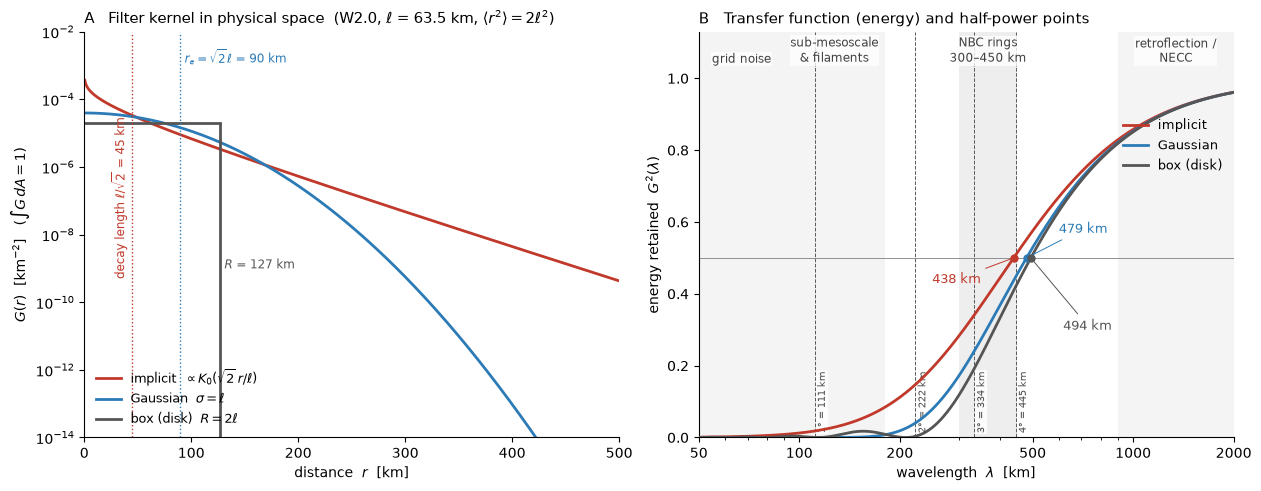

In [2]:
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.linewidth': 0.8, 'xtick.direction': 'out', 'ytick.direction': 'out', 'legend.frameon': False})
C = {'implicit': '#c0392b', 'gaussian': '#2c7bb6', 'box': '#555555'}

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)

# ---------------- Panel A: kernels in physical space
r = np.linspace(0.5, 500, 2000)
axA.semilogy(r, G_imp(r), color=C['implicit'], lw=2, label=r'implicit  $\propto K_0(\sqrt{2}\,r/\ell)$')
axA.semilogy(r, G_gau(r), color=C['gaussian'], lw=2, label=r'Gaussian  $\sigma=\ell$')
rb = np.array([0.5, R - 1e-6, R + 1e-6, 500])
axA.semilogy(rb[:2], [1/(np.pi*R**2)]*2, color=C['box'], lw=2, label=rf'box (disk)  $R=2\ell$')
axA.vlines(R, 1e-14, 1/(np.pi*R**2), color=C['box'], lw=2)
ylo, yhi = 1e-14, 1e-2
axA.set_ylim(ylo, yhi); axA.set_xlim(0, 500)
# e-folding markers
axA.axvline(r_e_gau, color=C['gaussian'], ls=':', lw=1)
axA.text(r_e_gau + 4, 3e-3, rf'$r_e=\sqrt{{2}}\ell$ = {r_e_gau:.0f} km', color=C['gaussian'], fontsize=8.5, va='top')
axA.axvline(r_e_imp, color=C['implicit'], ls=':', lw=1)
axA.text(r_e_imp - 4, 3e-5, rf'decay length $\ell/\sqrt{{2}}$ = {r_e_imp:.0f} km', color=C['implicit'], fontsize=8.5, ha='right', rotation=90, va='top')
axA.text(R + 4, 1e-9, rf'$R$ = {R:.0f} km', color=C['box'], fontsize=8.5)
axA.set_xlabel('distance  $r$  [km]'); axA.set_ylabel(r'$G(r)$  [km$^{-2}$]   ($\int G\,dA = 1$)')
axA.set_title(rf'A   Filter kernel in physical space  (W2.0, $\ell$ = {ell} km, $\langle r^2\rangle = 2\ell^2$)', loc='left', fontsize=10.5)
axA.legend(loc='lower left', fontsize=9)

# ---------------- Panel B: energy transfer G^2(lambda)
lam = np.logspace(np.log10(50), np.log10(2000), 1500)
# scale annotations (shaded, behind curves)
bands = [((50, 90), 'grid noise', 0.10), ((90, 180), 'sub-mesoscale\n& filaments', 0.10),
         ((300, 450), 'NBC rings\n300–450 km', 0.16), ((900, 2000), 'retroflection /\nNECC', 0.10)]
for (a, b), txt, alpha in bands:
    axB.axvspan(a, b, color='0.6', alpha=alpha, lw=0, zorder=0)
    axB.text(np.sqrt(a*b), 1.035, txt, ha='center', va='bottom', fontsize=8.5, color='0.25',
             bbox=dict(facecolor='white', edgecolor='none', pad=0.5, alpha=0.8), zorder=2)
for d in (1, 2, 3, 4):
    axB.axvline(d*DEG, color='0.35', lw=0.7, ls='--', zorder=1)
    axB.text(d*DEG * 1.015, 0.012, f'{d}° = {d*DEG:.0f} km', fontsize=7.5, color='0.3', va='bottom', ha='left', rotation=90,
             bbox=dict(facecolor='white', edgecolor='none', pad=0.6, alpha=0.85), zorder=2)
axB.semilogx(lam, T_imp(lam), color=C['implicit'], lw=2, label='implicit', zorder=3)
axB.semilogx(lam, T_gau(lam), color=C['gaussian'], lw=2, label='Gaussian', zorder=3)
axB.semilogx(lam, T_box(lam), color=C['box'], lw=2, label='box (disk)', zorder=3)
axB.axhline(0.5, color='0.5', lw=0.6, zorder=1)
offs = {'implicit': (-8, 0.43), 'gaussian': (0, 0.57), 'box': (8, 0.30)}
for k, v in lam_half.items():
    axB.plot(v, 0.5, 'o', color=C[k], ms=5, zorder=4)
    dx, yt = offs[k]
    axB.annotate(f'{v:.0f} km', xy=(v, 0.5), xytext=(v * (1.25 if dx >= 0 else 0.8), yt), color=C[k], fontsize=9,
                 ha='left' if dx >= 0 else 'right', arrowprops=dict(arrowstyle='-', color=C[k], lw=0.7))
axB.set_xlim(50, 2000); axB.set_ylim(0, 1.13)
axB.set_xticks([50, 100, 200, 500, 1000, 2000]); axB.set_xticklabels(['50', '100', '200', '500', '1000', '2000'])
axB.set_xlabel(r'wavelength  $\lambda$  [km]'); axB.set_ylabel(r'energy retained  $G^2(\lambda)$')
axB.set_title('B   Transfer function (energy) and half-power points', loc='left', fontsize=10.5)
axB.legend(loc='center right', bbox_to_anchor=(1.0, 0.72), fontsize=9)

out_dir = '/work/bk1450/b383184/Amazon/Mercator/implicit_run/analysis/greens_function'
os.makedirs(out_dir, exist_ok=True)
for ext in ('png', 'pdf'):
    fig.savefig(f'{out_dir}/fig_greens_transfer_W2.0.{ext}', dpi=300, bbox_inches='tight')
print('saved', out_dir)
extra = '/mnt/user-data/outputs'
if os.path.isdir(extra) and os.access(extra, os.W_OK):
    for ext in ('png', 'pdf'):
        shutil.copy(f'{out_dir}/fig_greens_transfer_W2.0.{ext}', extra)
    print('copied to', extra)
else:
    print(f'{extra} does not exist on this system - not copied')
plt.show()

**How to read the figure**
- **Similar core.** All three kernels average over roughly the same area; they share the same $\langle r^2\rangle$, i.e. the same "2° box".
- **Different tails.** The implicit filter has the sharpest centre and the longest tail. In panel B it cuts off least steeply:
  - its half-power point is at the shortest wavelength (438 km);
  - it still keeps ~11 % of the energy at 200 km;
  - it keeps slightly more than the others at long wavelengths (86 % at 1000 km, 91 % at 1300 km).
- **The Gaussian** cuts more steeply.
- **The box** has negative side lobes in $\mathrm{jinc}$, which appear as bumps in $G^2$ at short wavelengths (ringing).
- **Consequence for W2.0.**
  - Grid noise and filaments (<150 km) are removed almost completely.
  - The **NBC-ring band (300–450 km) sits right at the half-power point**: the implicit filter keeps 28–52 % of the energy at those wavelengths, so rings are only partly removed.
  - The retroflection and NECC scales (>900 km) are kept largely intact (>80 %).

# Conceptual view of the W2.0 filter

Two plain-language figures for intuition (no equations):
- **A. "The palm":** how much weight the filter gives to water at a given distance from a point.
- **B. "What gets removed":** for a feature of a given size (wavelength), how much of its energy the filter takes out.

Numbers behind them: 90 % of the smoothing weight lies within **~1.3°** (144 km) of the point. Features of **~4°** (438 km) lose half their energy. Below ~2.3° more than 80 % is removed; above ~7.4° less than 20 % is removed.

90% of the weight within r = 144 km = 1.30 deg
removal: 80% at 2.29 deg, 50% at 3.95 deg, 20% at 7.40 deg


saved /work/bk1450/b383184/Amazon/Mercator/implicit_run/analysis/greens_function/fig_conceptual_filter_W2.0.png/.pdf


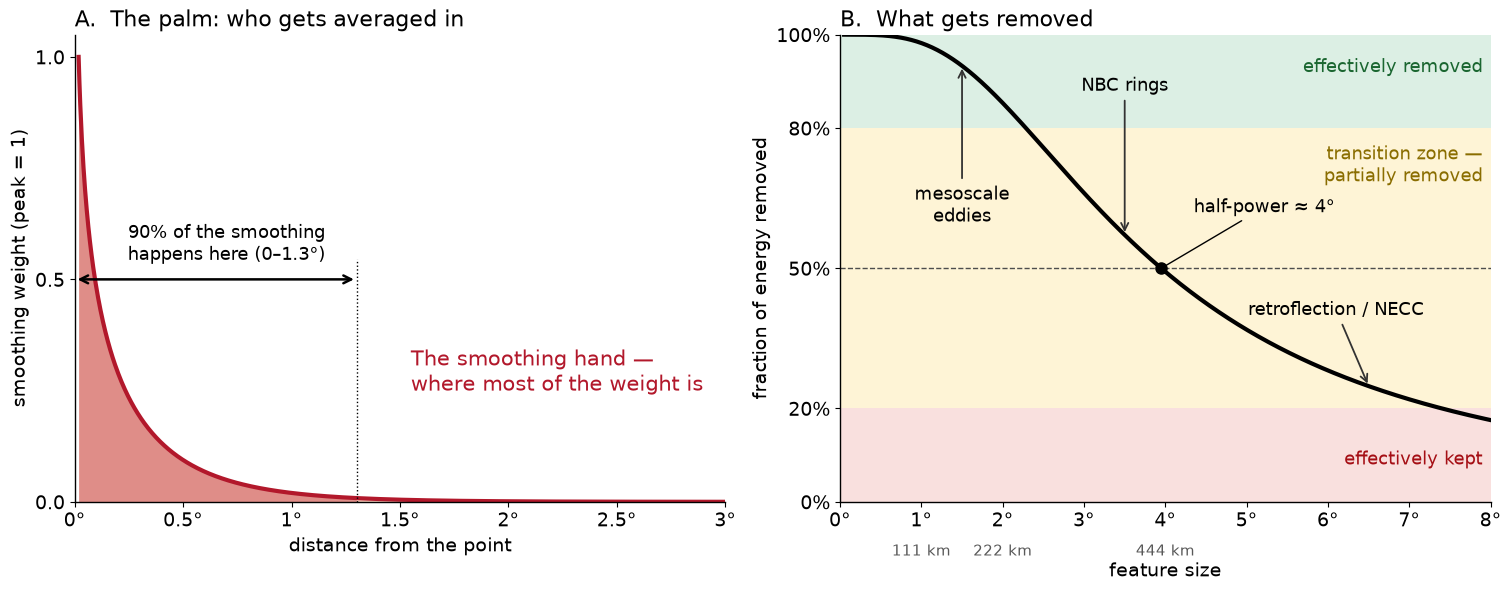

In [3]:
from scipy.special import k1
DEG = 111.0
a = np.sqrt(2) / ell
# fraction of weight inside radius r for the (unit-integral) implicit kernel: 1 - (a r) K1(a r)
r90 = brentq(lambda r: (1 - a*r*k1(a*r)) - 0.9, 1, 1000)
lam_half_deg = lam_half['implicit'] / DEG
lam80 = brentq(lambda l: (1 - T_imp(l)) - 0.8, 20, 5000) / DEG   # 80 % removed
lam20 = brentq(lambda l: (1 - T_imp(l)) - 0.2, 20, 5000) / DEG   # 20 % removed
print(f'90% of the weight within r = {r90:.0f} km = {r90/DEG:.2f} deg')
print(f'removal: 80% at {lam80:.2f} deg, 50% at {lam_half_deg:.2f} deg, 20% at {lam20:.2f} deg')

plt.rcParams.update({'font.size': 14, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.linewidth': 1.0})
figC, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.8), constrained_layout=True)
figC.patch.set_facecolor('white')

# ---------------- A: the palm
rd = np.linspace(2/DEG, 3, 800)                   # degrees, start at r = 2 km (K0 is singular at 0)
w = k0(np.sqrt(2) * rd * DEG / ell); w /= w[0]
ax1.fill_between(rd, 0, w, color='#f4a582', alpha=0.55, lw=0)
ax1.plot(rd, w, color='#b2182b', lw=3)
in90 = rd <= r90 / DEG
ax1.fill_between(rd[in90], 0, w[in90], color='#b2182b', alpha=0.35, lw=0)
ax1.axvline(r90/DEG, color='k', lw=1, ls=':', ymax=0.52)
ax1.annotate('', xy=(0, 0.50), xytext=(r90/DEG, 0.50), arrowprops=dict(arrowstyle='<->', color='k', lw=1.8))
ax1.text(r90/DEG/2 + 0.05, 0.53, f'90% of the smoothing\nhappens here (0–{r90/DEG:.1f}°)', ha='center', va='bottom', fontsize=13)
ax1.text(1.55, 0.25, 'The smoothing hand —\nwhere most of the weight is', fontsize=15, color='#b2182b')
ax1.set_xlim(0, 3); ax1.set_ylim(0, 1.05)
ax1.set_xticks([0, 0.5, 1, 1.5, 2, 2.5, 3]); ax1.set_xticklabels(['0°', '0.5°', '1°', '1.5°', '2°', '2.5°', '3°'])
ax1.set_yticks([0, 0.5, 1])
ax1.set_xlabel('distance from the point'); ax1.set_ylabel('smoothing weight (peak = 1)')
ax1.set_title('A.  The palm: who gets averaged in', loc='left', fontsize=16)

# ---------------- B: what gets removed
lamd = np.linspace(0.05, 8, 1000)
rem = 100 * (1 - T_imp(lamd * DEG))
ax2.axhspan(80, 100, color='#1a9850', alpha=0.15, lw=0)
ax2.axhspan(20, 80, color='#fee08b', alpha=0.35, lw=0)
ax2.axhspan(0, 20, color='#d73027', alpha=0.15, lw=0)
ax2.text(7.9, 92, 'effectively removed', ha='right', fontsize=13, color='#1a6630')
ax2.text(7.9, 72, 'transition zone —\npartially removed', ha='right', va='center', fontsize=13, color='#8a6d00')
ax2.text(7.9, 8, 'effectively kept', ha='right', fontsize=13, color='#a50f15')
ax2.plot(lamd, rem, color='k', lw=3)
ax2.axhline(50, color='0.3', lw=1, ls='--')
ax2.plot(lam_half_deg, 50, 'o', color='k', ms=8)
ax2.annotate(f'half-power ≈ {lam_half_deg:.0f}°', xy=(lam_half_deg, 50), xytext=(lam_half_deg + 0.4, 62),
             fontsize=13, arrowprops=dict(arrowstyle='-', color='k', lw=1))
def mark(x0, x1, label, y):
    xm = 0.5 * (x0 + x1); ym = 100 * (1 - T_imp(xm * DEG))
    ax2.annotate(label, xy=(xm, ym), xytext=(xm, y), ha='center', fontsize=13,
                 arrowprops=dict(arrowstyle='->', color='0.2', lw=1.3))
mark(1, 2, 'mesoscale\neddies', 60)
mark(3, 4, 'NBC rings', 88)
ax2.annotate('retroflection / NECC', xy=(6.5, 100*(1 - T_imp(6.5*DEG))), xytext=(6.1, 40), ha='center', fontsize=13,
             arrowprops=dict(arrowstyle='->', color='0.2', lw=1.3))
ax2.set_xlim(0, 8); ax2.set_ylim(0, 100)
ax2.set_xticks(range(0, 9)); ax2.set_xticklabels([f'{d}°' for d in range(0, 9)])
ax2.set_yticks([0, 20, 50, 80, 100]); ax2.set_yticklabels(['0%', '20%', '50%', '80%', '100%'])
for d in (1, 2, 4):
    ax2.text(d, -9, f'{d*DEG:.0f} km', ha='center', va='top', fontsize=11, color='0.35')
ax2.set_xlabel('feature size', labelpad=22); ax2.set_ylabel('fraction of energy removed')
ax2.set_title('B.  What gets removed', loc='left', fontsize=16)

for ext in ('png', 'pdf'):
    figC.savefig(f'{out_dir}/fig_conceptual_filter_W2.0.{ext}', dpi=300, bbox_inches='tight', facecolor='white')
print('saved', f'{out_dir}/fig_conceptual_filter_W2.0.png/.pdf')
plt.show()